<div style="background: linear-gradient(135deg,#0f2027,#203a43,#2c5364); padding:30px; border-radius:15px; color:white; font-family:Arial;">

<h1 style="text-align:center; color:#4FC3F7;">🌿 Plant Disease Detection with Deep Learning & Grad-CAM</h1>

<hr style="border:1px solid #4FC3F7;">

<h2 style="color:#FFD54F;"> Overview</h2>

<p style="color:#FF6B6B; font-size:16px; line-height:1.6;">
An end-to-end deep learning system that classifies <strong>38 plant disease conditions</strong> 
across <strong>14 crop species</strong> from leaf images, using a custom 
<strong>ResNet50</strong> architecture with <strong>Grad-CAM</strong> explainability 
to highlight infected regions and make model decisions transparent and actionable.
</p>

<hr>

<h2 style="color:#FFD54F;">🌱 Importance</h2>

<p style="color:#FF6B6B; font-size:16px; line-height:1.6;">
Plant diseases cause significant crop losses every year, directly threatening 
<strong>food security</strong> and <strong>farmer income</strong>, especially in regions 
where agricultural expertise is scarce. Current diagnosis methods depend on 
manual inspection by specialists, which is <strong>slow, expensive, and hard to scale</strong>.
</p>

<hr>

<h2 style="color:#FFD54F;"> Objectives</h2>

<div style="background:#1e293b; padding:20px; border-radius:10px;">

<ul style="line-height:1.8; font-size:15px; color:#8BE9FD;">
<li>Build a <strong>high-accuracy classifier</strong> trained on <strong>87,000+ real leaf images</strong> across 38 disease classes</li>
<li>Integrate <strong>Grad-CAM</strong> to visually explain which leaf regions drive each prediction</li>
<li>Deliver a complete pipeline covering <strong>EDA, training, evaluation, and explainability</strong></li>
<li>Demonstrate a practical, <strong>scalable AI solution</strong> for early plant disease intervention in real agricultural settings</li>
</ul>

</div>

</div>

In [1]:
import subprocess

subprocess.run(
    [
        "pip", "install", "torch==2.2.0", "torchvision==0.17.2",
        "--index-url", "https://download.pytorch.org/whl/cu118",
        "--force-reinstall", "--no-cache-dir"
    ],
    stdout=subprocess.DEVNULL,   
    stderr=subprocess.DEVNULL    
)

CompletedProcess(args=['pip', 'install', 'torch==2.2.0', 'torchvision==0.17.2', '--index-url', 'https://download.pytorch.org/whl/cu118', '--force-reinstall', '--no-cache-dir'], returncode=1)

<h2 style="
text-align:center;
color:#1a237e;
font-weight:bold;
font-size:32px;
text-shadow:2px 2px 8px rgba(26,35,126,0.4);
letter-spacing:1px;">
Imports</h2>

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from PIL import Image
import cv2
import warnings
warnings.filterwarnings("ignore")

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, models
from torchvision.utils import make_grid
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
import json
import random
from collections import Counter

plt.rcParams["figure.dpi"] = 130
plt.rcParams["font.family"] = "DejaVu Sans"

<h2 style="
text-align:center;
color:#1a237e;
font-weight:bold;
font-size:32px;
text-shadow:2px 2px 8px rgba(26,35,126,0.4);
letter-spacing:1px;">
Configuration</h2>

In [3]:
CONFIG = {
    "data_dir"       : "/kaggle/input/datasets/vipoooool/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)",
    "image_size"     : 128,
    "batch_size"     : 128,
    "num_epochs"     : 5,
    "learning_rate"  : 1e-4,
    "num_workers"    : 4,
    "seed"           : 42,
    "device"         : "cuda" if torch.cuda.is_available() else "cpu",
    "checkpoint_path": "/kaggle/working/best_model.pth",
}

random.seed(CONFIG["seed"])
np.random.seed(CONFIG["seed"])
torch.manual_seed(CONFIG["seed"])

print("Device:", CONFIG["device"])
print("CUDA Available:", torch.cuda.is_available())

Device: cuda
CUDA Available: True


<h2 style="
text-align:center;
color:#1a237e;
font-weight:bold;
font-size:32px;
text-shadow:2px 2px 8px rgba(26,35,126,0.4);
letter-spacing:1px;">
Load Dataset Paths</h2>

In [4]:
train_dir = os.path.join(CONFIG["data_dir"], "train")
valid_dir = os.path.join(CONFIG["data_dir"], "valid")

classes = sorted(os.listdir(train_dir))
num_classes = len(classes)
class_to_idx = {cls: idx for idx, cls in enumerate(classes)}

train_paths, train_labels = [], []
valid_paths, valid_labels = [], []

for cls in classes:
    for img in os.listdir(os.path.join(train_dir, cls)):
        train_paths.append(os.path.join(train_dir, cls, img))
        train_labels.append(class_to_idx[cls])

for cls in classes:
    for img in os.listdir(os.path.join(valid_dir, cls)):
        valid_paths.append(os.path.join(valid_dir, cls, img))
        valid_labels.append(class_to_idx[cls])

print(f"Number of classes  : {num_classes}")
print(f"Training samples   : {len(train_paths)}")
print(f"Validation samples : {len(valid_paths)}")

Number of classes  : 38
Training samples   : 70295
Validation samples : 17572


<h2 style="
text-align:center;
color:#1a237e;
font-weight:bold;
font-size:32px;
text-shadow:2px 2px 8px rgba(26,35,126,0.4);
letter-spacing:1px;">
EDA: Class Distribution</h2>

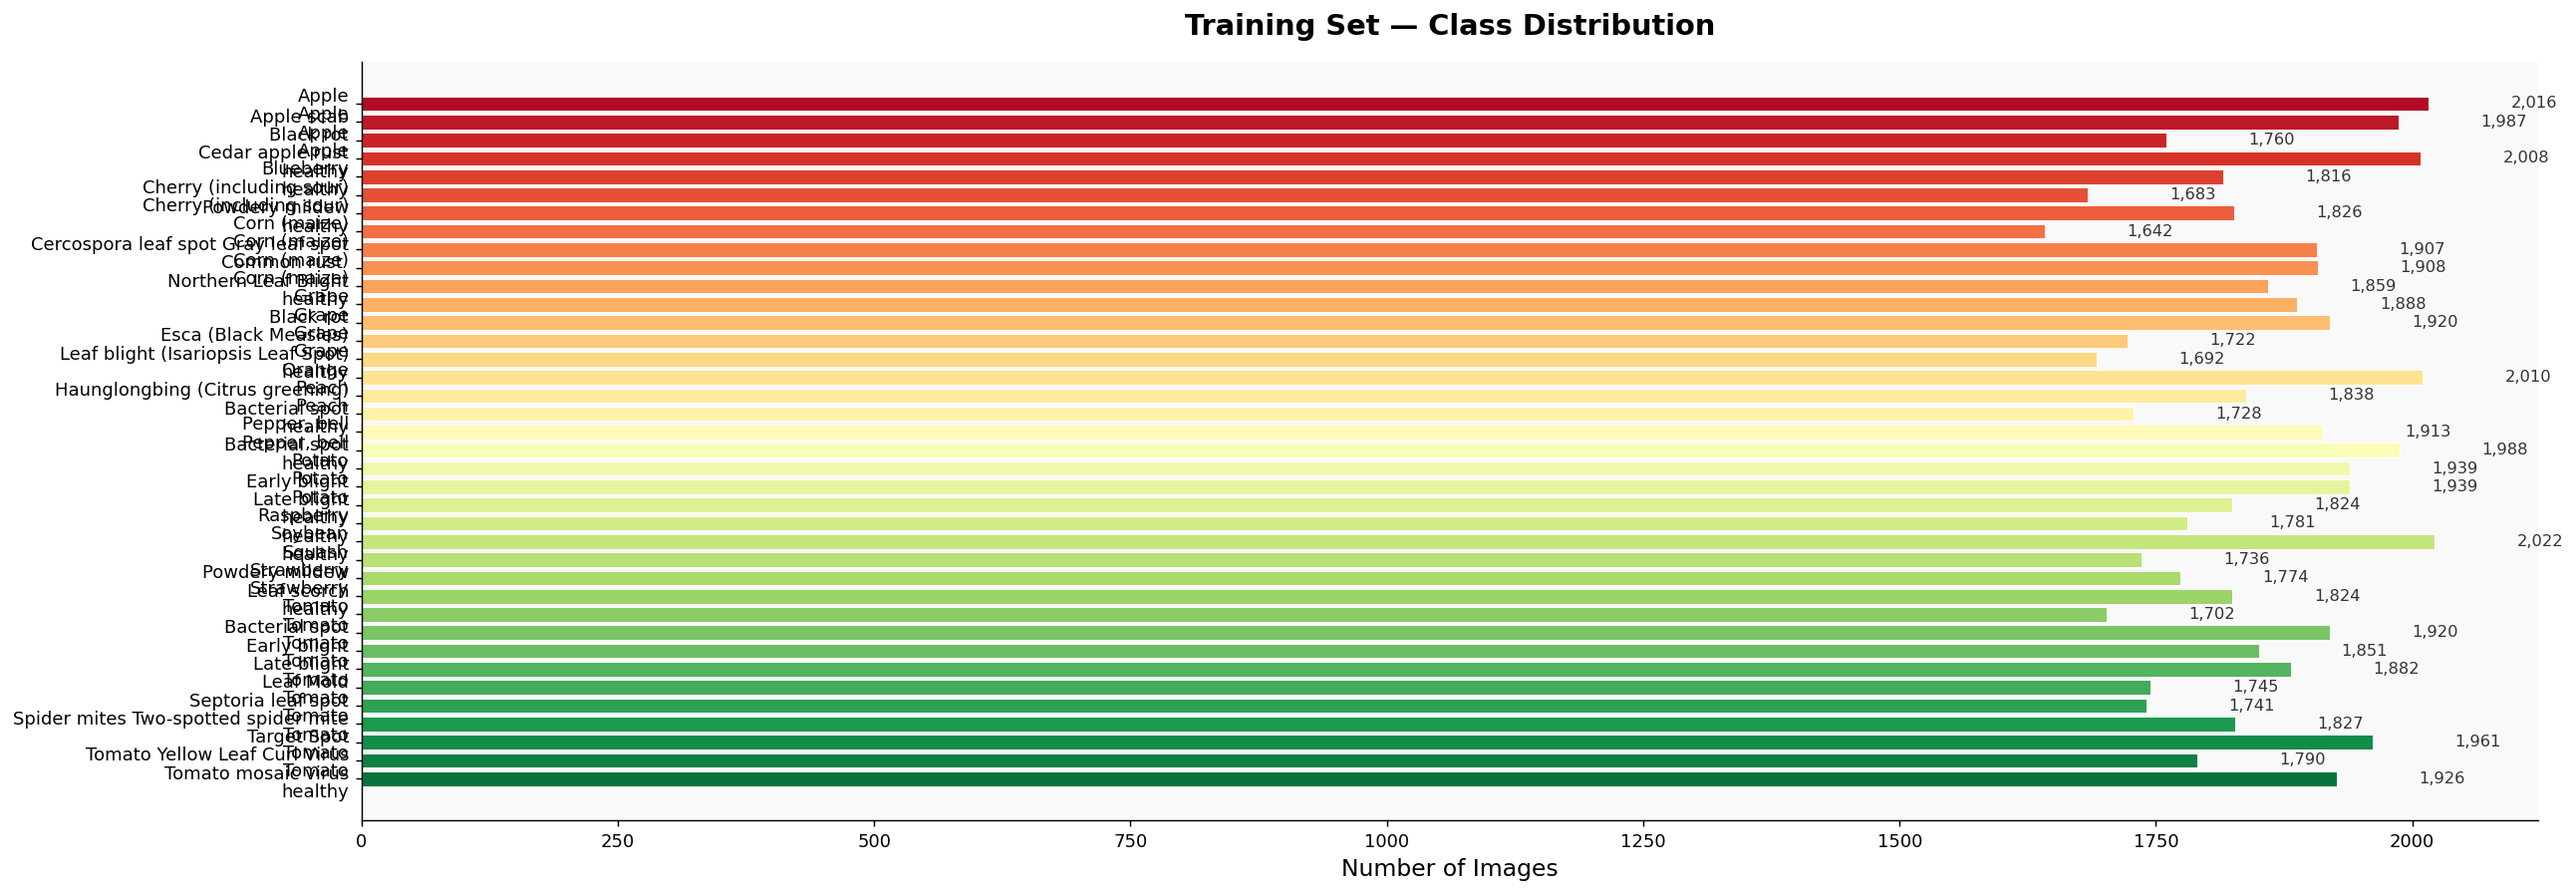

In [5]:
train_counts = Counter(train_labels)
class_names_short = [c.replace("___", "\n").replace("_", " ") for c in classes]
counts = [train_counts[i] for i in range(num_classes)]

palette = sns.color_palette("RdYlGn", num_classes)

fig, ax = plt.subplots(figsize=(20, 7))
bars = ax.barh(class_names_short, counts, color=palette, edgecolor="white", linewidth=0.5)
ax.set_xlabel("Number of Images", fontsize=13)
ax.set_title("Training Set — Class Distribution", fontsize=16, fontweight="bold", pad=15)
ax.invert_yaxis()

for bar, count in zip(bars, counts):
    ax.text(bar.get_width() + 80, bar.get_y() + bar.get_height() / 2,
            f"{count:,}", va="center", fontsize=9, color="#333333")

ax.spines[["top", "right"]].set_visible(False)
ax.set_facecolor("#f9f9f9")
fig.patch.set_facecolor("#ffffff")
plt.tight_layout()
plt.savefig("/kaggle/working/class_distribution.png", bbox_inches="tight")
plt.show()

<h2 style="
text-align:center;
color:#1a237e;
font-weight:bold;
font-size:32px;
text-shadow:2px 2px 8px rgba(26,35,126,0.4);
letter-spacing:1px;">
EDA: Sample Images Per Class</h2>

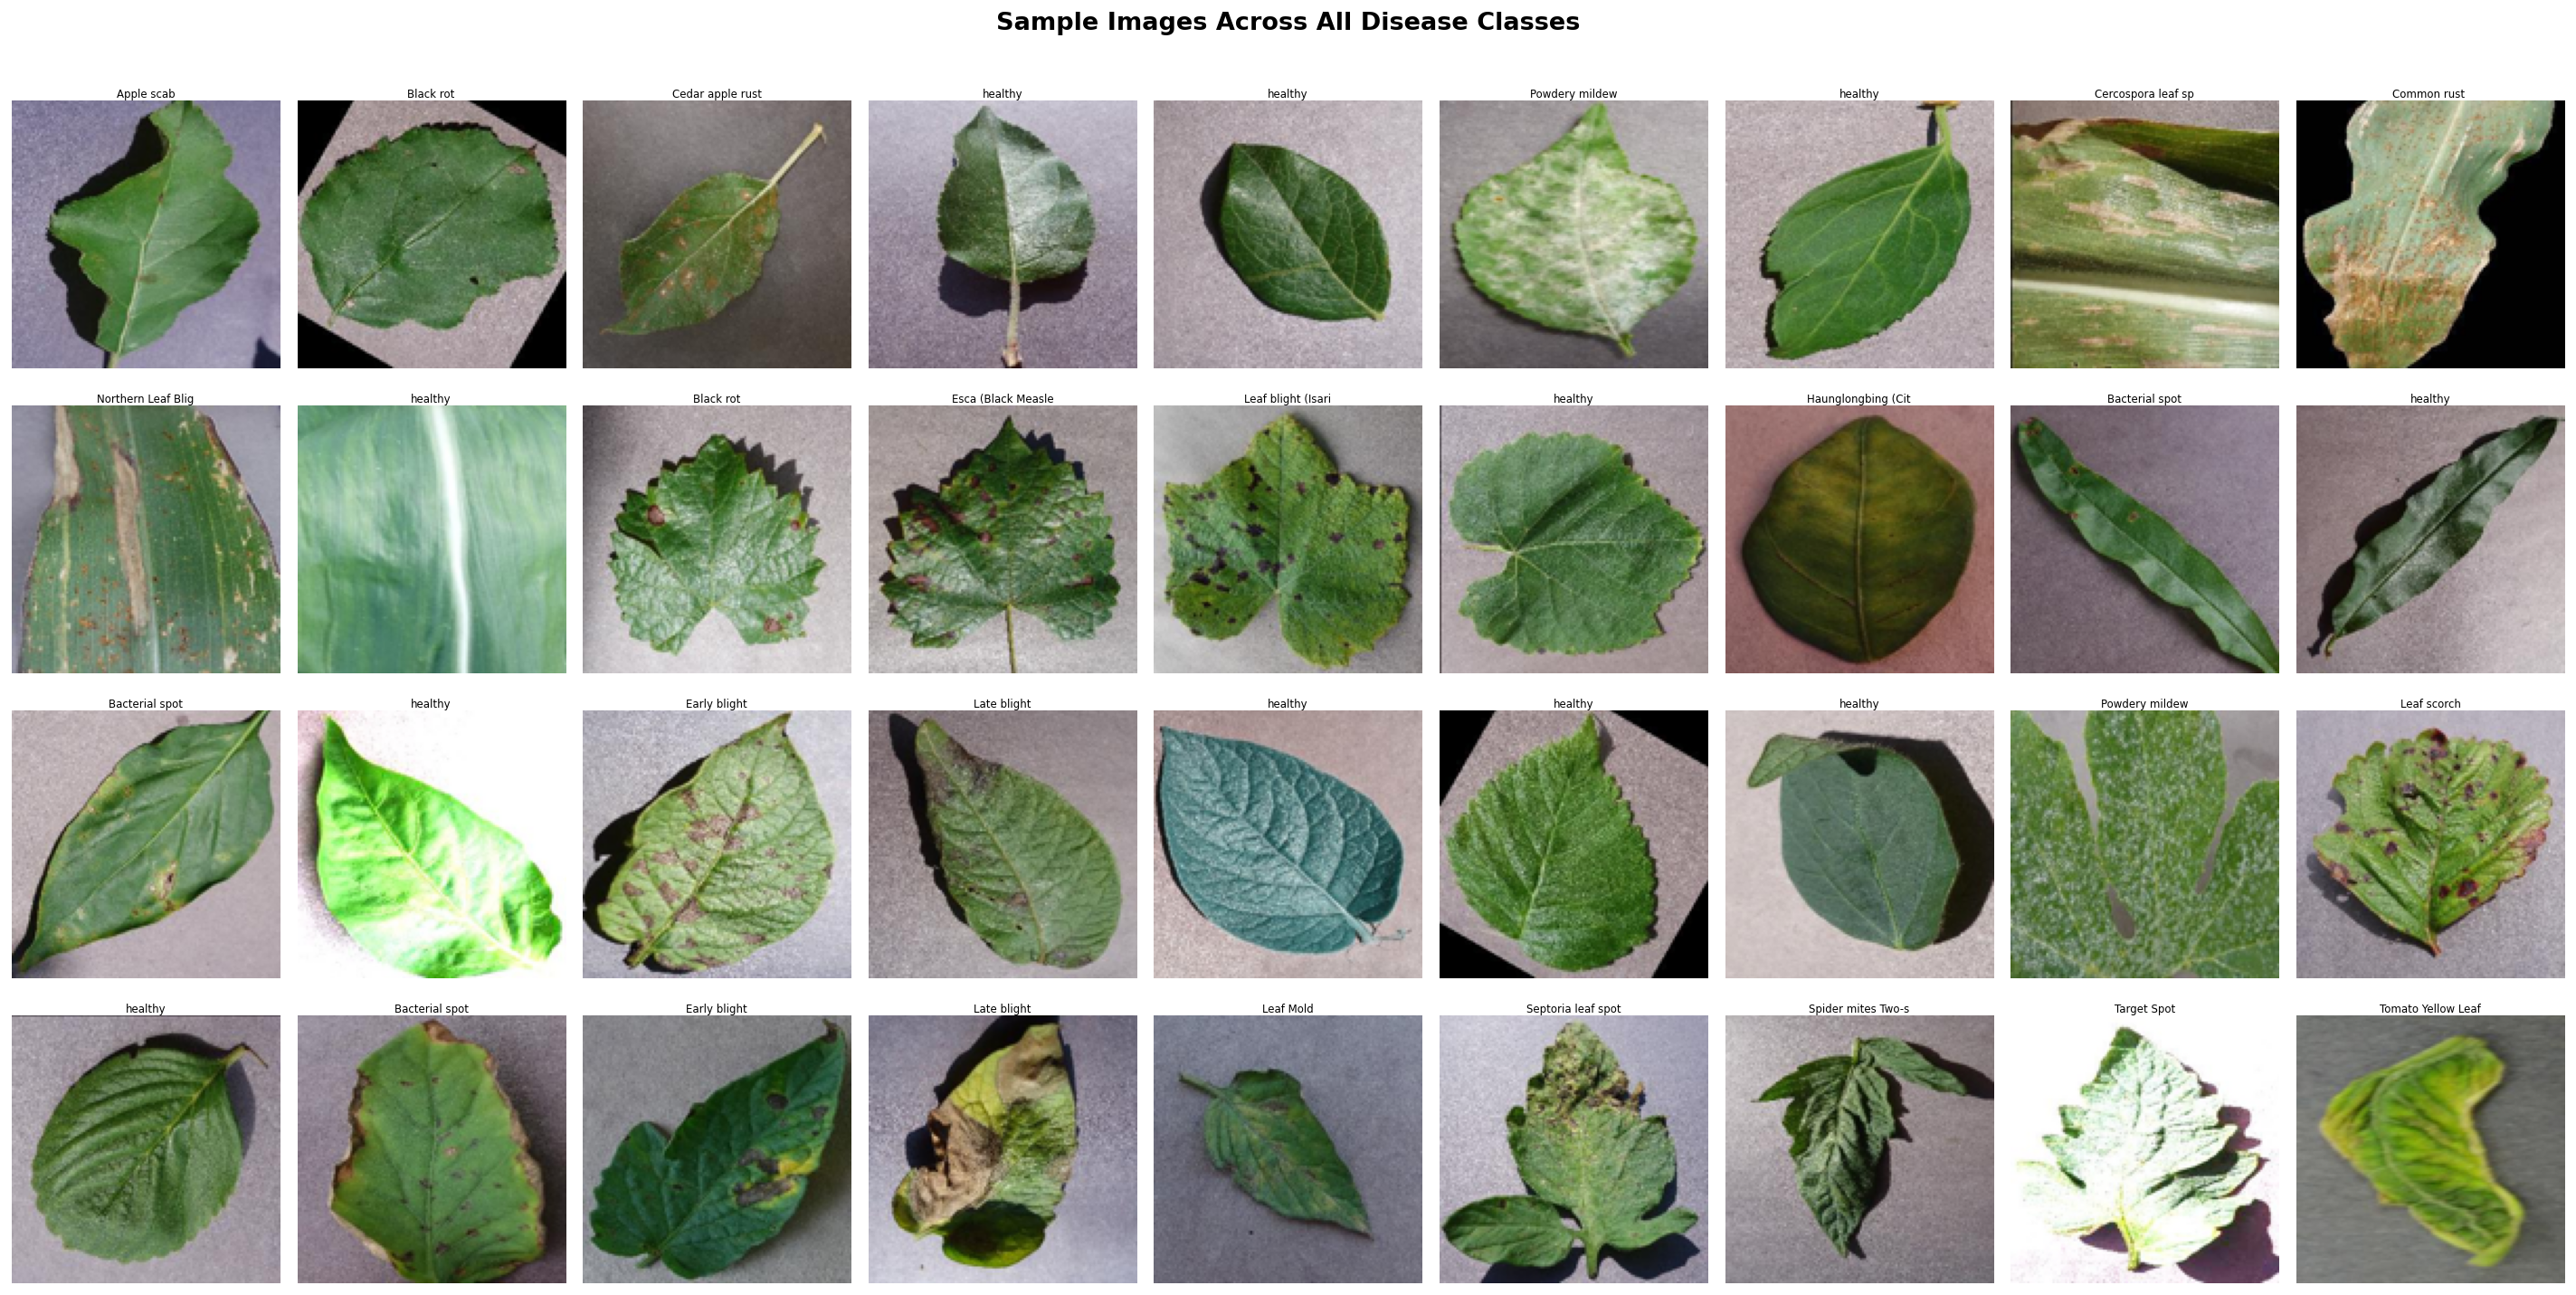

In [6]:
fig, axes = plt.subplots(4, 9, figsize=(22, 11))
axes = axes.flatten()

for idx, cls in enumerate(classes[:36]):
    cls_dir = os.path.join(train_dir, cls)
    img_file = random.choice(os.listdir(cls_dir))
    img = Image.open(os.path.join(cls_dir, img_file)).convert("RGB")
    img = img.resize((128, 128))
    axes[idx].imshow(img)
    axes[idx].set_title(cls.split("___")[-1].replace("_", " ")[:18], fontsize=6.5, pad=2)
    axes[idx].axis("off")

for idx in range(len(classes), len(axes)):
    axes[idx].axis("off")

fig.suptitle("Sample Images Across All Disease Classes", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("/kaggle/working/sample_images.png", bbox_inches="tight")
plt.show()

<h2 style="
text-align:center;
color:#1a237e;
font-weight:bold;
font-size:32px;
text-shadow:2px 2px 8px rgba(26,35,126,0.4);
letter-spacing:1px;">
EDA: Image Size Distribution</h2>

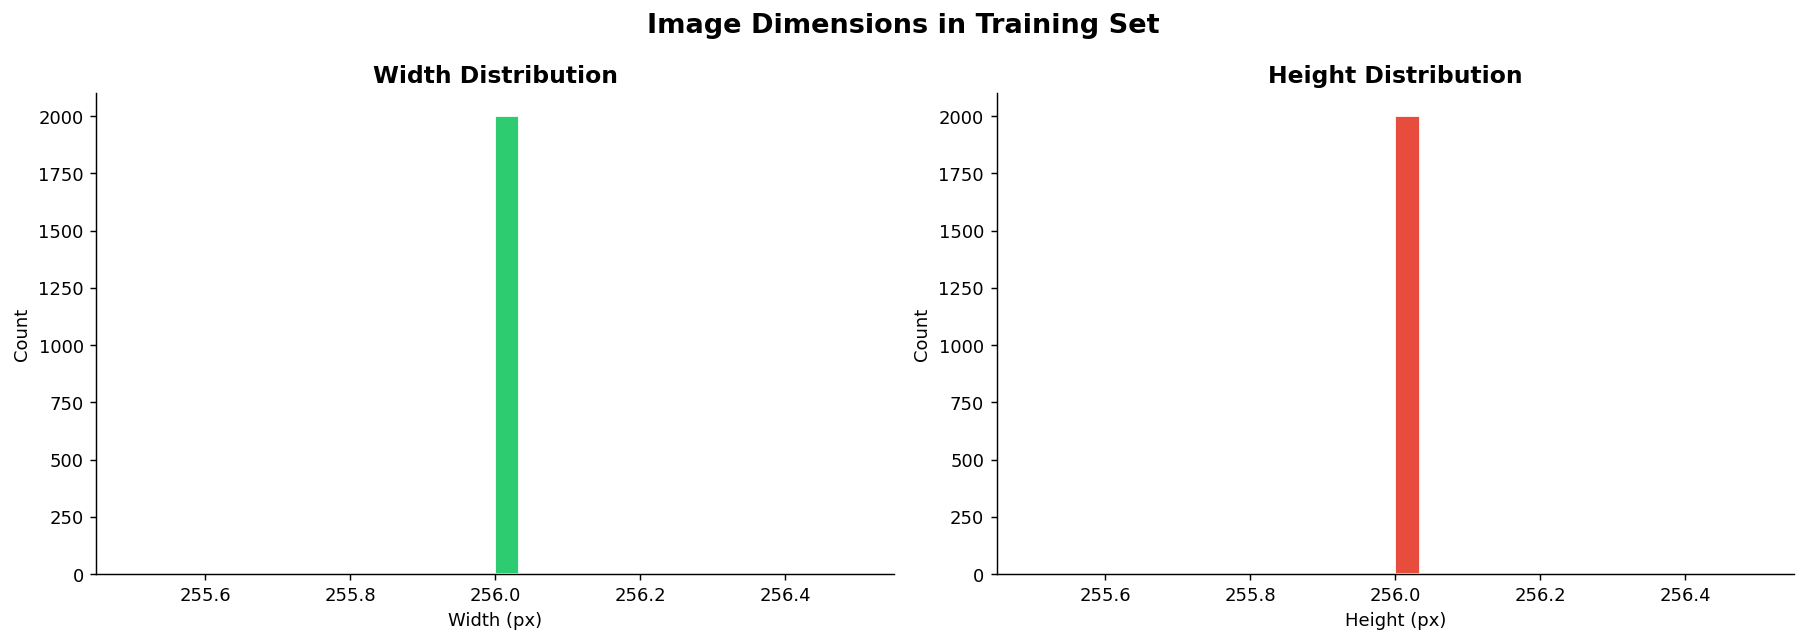

In [7]:
sample_paths = random.sample(train_paths, min(2000, len(train_paths)))
widths, heights = [], []

for p in sample_paths:
    img = Image.open(p)
    w, h = img.size
    widths.append(w)
    heights.append(h)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(widths, bins=30, color="#2ecc71", edgecolor="white")
axes[0].set_title("Width Distribution", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Width (px)")
axes[0].set_ylabel("Count")
axes[0].spines[["top", "right"]].set_visible(False)

axes[1].hist(heights, bins=30, color="#e74c3c", edgecolor="white")
axes[1].set_title("Height Distribution", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Height (px)")
axes[1].set_ylabel("Count")
axes[1].spines[["top", "right"]].set_visible(False)

fig.suptitle("Image Dimensions in Training Set", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("/kaggle/working/image_dimensions.png", bbox_inches="tight")
plt.show()

<h2 style="
text-align:center;
color:#1a237e;
font-weight:bold;
font-size:32px;
text-shadow:2px 2px 8px rgba(26,35,126,0.4);
letter-spacing:1px;">
EDA: Average Pixel Intensity Per Plant</h2>

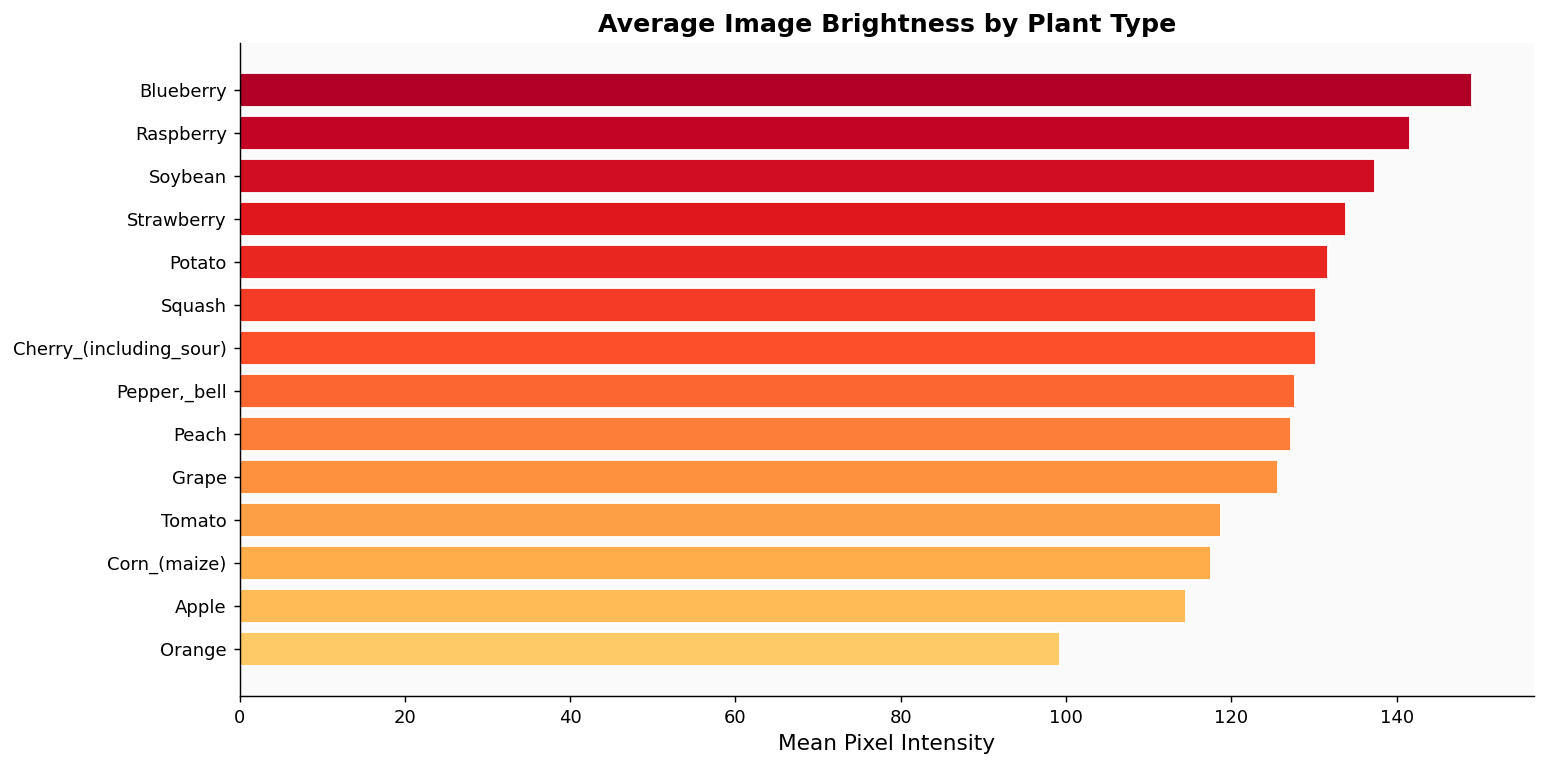

In [8]:
plants = list(set([c.split("___")[0] for c in classes]))
plant_brightness = {}

for plant in plants:
    plant_classes = [c for c in classes if c.startswith(plant)]
    values = []
    for cls in plant_classes:
        cls_dir = os.path.join(train_dir, cls)
        for img_file in random.sample(os.listdir(cls_dir), min(20, len(os.listdir(cls_dir)))):
            img = Image.open(os.path.join(cls_dir, img_file)).convert("L")
            values.append(np.mean(np.array(img)))
    plant_brightness[plant] = np.mean(values)

sorted_plants = sorted(plant_brightness, key=plant_brightness.get)
vals = [plant_brightness[p] for p in sorted_plants]

fig, ax = plt.subplots(figsize=(12, 6))
colors = plt.cm.YlOrRd(np.linspace(0.3, 0.9, len(sorted_plants)))
ax.barh(sorted_plants, vals, color=colors, edgecolor="white")
ax.set_xlabel("Mean Pixel Intensity", fontsize=12)
ax.set_title("Average Image Brightness by Plant Type", fontsize=14, fontweight="bold")
ax.spines[["top", "right"]].set_visible(False)
ax.set_facecolor("#fafafa")
plt.tight_layout()
plt.savefig("/kaggle/working/brightness_per_plant.png", bbox_inches="tight")
plt.show()

<h2 style="
text-align:center;
color:#1a237e;
font-weight:bold;
font-size:32px;
text-shadow:2px 2px 8px rgba(26,35,126,0.4);
letter-spacing:1px;">
EDA: Healthy vs Diseased Ratio</h2>

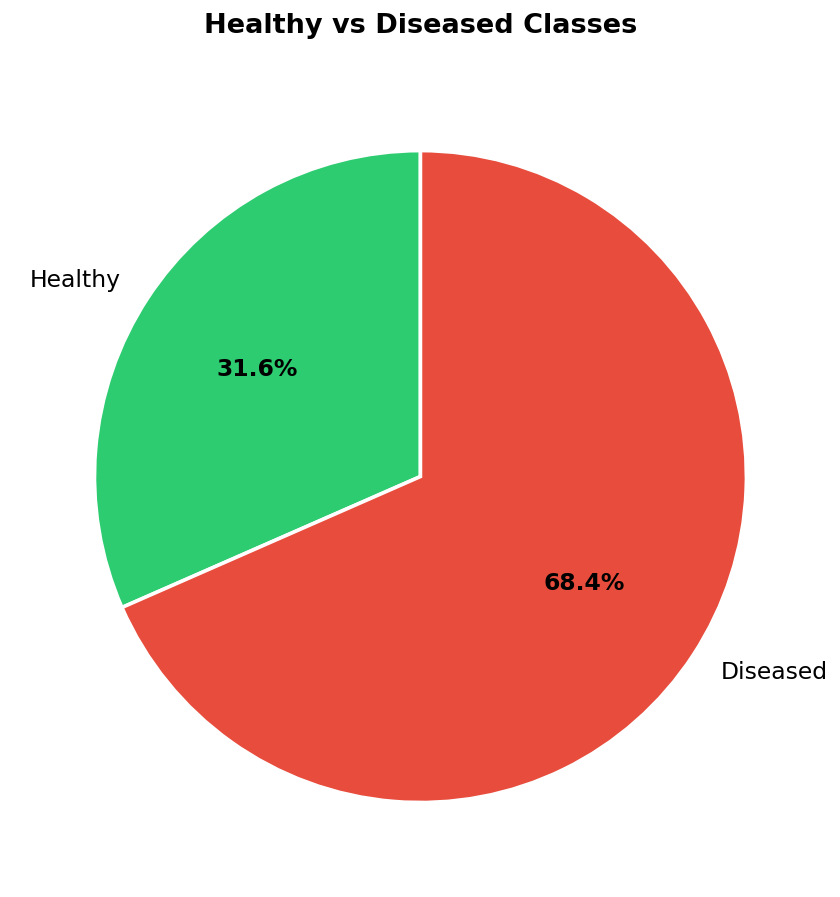

In [9]:
healthy_count  = sum(1 for c in classes if "healthy" in c.lower())
diseased_count = num_classes - healthy_count

fig, ax = plt.subplots(figsize=(7, 7))
wedges, texts, autotexts = ax.pie(
    [healthy_count, diseased_count],
    labels=["Healthy", "Diseased"],
    autopct="%1.1f%%",
    colors=["#2ecc71", "#e74c3c"],
    startangle=90,
    wedgeprops=dict(edgecolor="white", linewidth=2),
    textprops=dict(fontsize=13)
)
for autotext in autotexts:
    autotext.set_fontsize(13)
    autotext.set_fontweight("bold")

ax.set_title("Healthy vs Diseased Classes", fontsize=15, fontweight="bold", pad=20)
plt.tight_layout()
plt.savefig("/kaggle/working/healthy_vs_diseased.png", bbox_inches="tight")
plt.show()

<h2 style="
text-align:center;
color:#1a237e;
font-weight:bold;
font-size:32px;
text-shadow:2px 2px 8px rgba(26,35,126,0.4);
letter-spacing:1px;">
 Dataset Class</h2>

In [10]:
class PlantDiseaseDataset(Dataset):
    def __init__(self, paths, labels, transform=None):
        self.paths     = paths
        self.labels    = labels
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img   = Image.open(self.paths[idx]).convert("RGB")
        label = self.labels[idx]
        if self.transform:
            img = self.transform(img)
        return img, label

<h2 style="
text-align:center;
color:#1a237e;
font-weight:bold;
font-size:32px;
text-shadow:2px 2px 8px rgba(26,35,126,0.4);
letter-spacing:1px;">
Transforms and DataLoaders</h2>

In [11]:
train_transform = transforms.Compose([
    transforms.Resize((CONFIG["image_size"], CONFIG["image_size"])),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

valid_transform = transforms.Compose([
    transforms.Resize((CONFIG["image_size"], CONFIG["image_size"])),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

train_dataset = PlantDiseaseDataset(train_paths, train_labels, train_transform)
valid_dataset = PlantDiseaseDataset(valid_paths, valid_labels, valid_transform)

train_loader = DataLoader(train_dataset, batch_size=CONFIG["batch_size"],
                          shuffle=True,  num_workers=CONFIG["num_workers"], pin_memory=True)
valid_loader = DataLoader(valid_dataset, batch_size=CONFIG["batch_size"],
                          shuffle=False, num_workers=CONFIG["num_workers"], pin_memory=True)

print(f"Train batches : {len(train_loader)}")
print(f"Valid batches : {len(valid_loader)}")

Train batches : 550
Valid batches : 138


<h2 style="
text-align:center;
color:#1a237e;
font-weight:bold;
font-size:32px;
text-shadow:2px 2px 8px rgba(26,35,126,0.4);
letter-spacing:1px;">
Custom Model with Grad-CAM Support</h2>

In [12]:
train_transform = transforms.Compose([
    transforms.Resize((CONFIG["image_size"], CONFIG["image_size"])),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

valid_transform = transforms.Compose([
    transforms.Resize((CONFIG["image_size"], CONFIG["image_size"])),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

train_dataset = PlantDiseaseDataset(train_paths, train_labels, train_transform)
valid_dataset = PlantDiseaseDataset(valid_paths, valid_labels, valid_transform)

train_loader = DataLoader(train_dataset, batch_size=CONFIG["batch_size"],
                          shuffle=True,  num_workers=CONFIG["num_workers"],
                          pin_memory=True, persistent_workers=True)
valid_loader = DataLoader(valid_dataset, batch_size=CONFIG["batch_size"],
                          shuffle=False, num_workers=CONFIG["num_workers"],
                          pin_memory=True, persistent_workers=True)

print(f"Train batches : {len(train_loader)}")
print(f"Valid batches : {len(valid_loader)}")

Train batches : 550
Valid batches : 138


<h2 style="
text-align:center;
color:#1a237e;
font-weight:bold;
font-size:27px;
text-shadow:2px 2px 8px rgba(26,35,126,0.4);
letter-spacing:1px;">
Plant Disease Classification Model with ResNet50 Backbone and Grad-CAM Hooks</h2>

In [13]:
class PlantDiseaseNet(nn.Module):
    def __init__(self, num_classes, dropout=0.4):
        super(PlantDiseaseNet, self).__init__()
        backbone = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

        self.features = nn.Sequential(*list(backbone.children())[:-2])
        self.pool     = nn.AdaptiveAvgPool2d(1)

        in_features = 2048
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(in_features, 512),
            nn.ReLU(),
            nn.Dropout(dropout / 2),
            nn.Linear(512, num_classes)
        )

        self.gradients   = None
        self.activations = None

        self.features[-1].register_forward_hook(self._save_activation)
        self.features[-1].register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, input, output):
        self.activations = output

    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

model = PlantDiseaseNet(num_classes=num_classes).to(CONFIG["device"])
print(f"Model parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 183MB/s]


Model parameters: 24,576,614


<h2 style="
text-align:center;
color:#1a237e;
font-weight:bold;
font-size:32px;
text-shadow:2px 2px 8px rgba(26,35,126,0.4);
letter-spacing:1px;">
Loss, Optimizer, Scheduler</h2>

In [14]:
 criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(model.parameters(),
                        lr=CONFIG["learning_rate"],
                        weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer,
                                                   T_max=CONFIG["num_epochs"],
                                                   eta_min=1e-6)

<h2 style="
text-align:center;
color:#1a237e;
font-weight:bold;
font-size:32px;
text-shadow:2px 2px 8px rgba(26,35,126,0.4);
letter-spacing:1px;">
Training Loop</h2>

In [15]:
scaler = torch.cuda.amp.GradScaler()

history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
best_val_acc = 0.0

for epoch in range(1, CONFIG["num_epochs"] + 1):

    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(CONFIG["device"]), labels.to(CONFIG["device"])
        optimizer.zero_grad()

        with torch.cuda.amp.autocast():
            outputs = model(images)
            loss    = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * images.size(0)
        _, preds = outputs.max(1)
        correct  += preds.eq(labels).sum().item()
        total    += labels.size(0)

    train_loss = running_loss / total
    train_acc  = correct / total

    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in valid_loader:
            images, labels = images.to(CONFIG["device"]), labels.to(CONFIG["device"])
            with torch.cuda.amp.autocast():
                outputs = model(images)
                loss    = criterion(outputs, labels)
            val_loss    += loss.item() * images.size(0)
            _, preds     = outputs.max(1)
            val_correct += preds.eq(labels).sum().item()
            val_total   += labels.size(0)

    val_loss = val_loss / val_total
    val_acc  = val_correct / val_total

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), CONFIG["checkpoint_path"])

    scheduler.step()

    print(f"Epoch [{epoch:02d}/{CONFIG['num_epochs']}]  "
          f"Train Loss: {train_loss:.4f}  Train Acc: {train_acc:.4f}  "
          f"Val Loss: {val_loss:.4f}  Val Acc: {val_acc:.4f}")

print(f"\nBest Validation Accuracy: {best_val_acc:.4f}")

Epoch [01/5]  Train Loss: 1.0323  Train Acc: 0.9067  Val Loss: 0.7091  Val Acc: 0.9910
Epoch [02/5]  Train Loss: 0.7167  Train Acc: 0.9928  Val Loss: 0.6918  Val Acc: 0.9947
Epoch [03/5]  Train Loss: 0.7005  Train Acc: 0.9967  Val Loss: 0.6880  Val Acc: 0.9955
Epoch [04/5]  Train Loss: 0.6922  Train Acc: 0.9986  Val Loss: 0.6826  Val Acc: 0.9969
Epoch [05/5]  Train Loss: 0.6894  Train Acc: 0.9991  Val Loss: 0.6797  Val Acc: 0.9973

Best Validation Accuracy: 0.9973


<h2 style="
text-align:center;
color:#1a237e;
font-weight:bold;
font-size:32px;
text-shadow:2px 2px 8px rgba(26,35,126,0.4);
letter-spacing:1px;">
Training Curves
</h2>

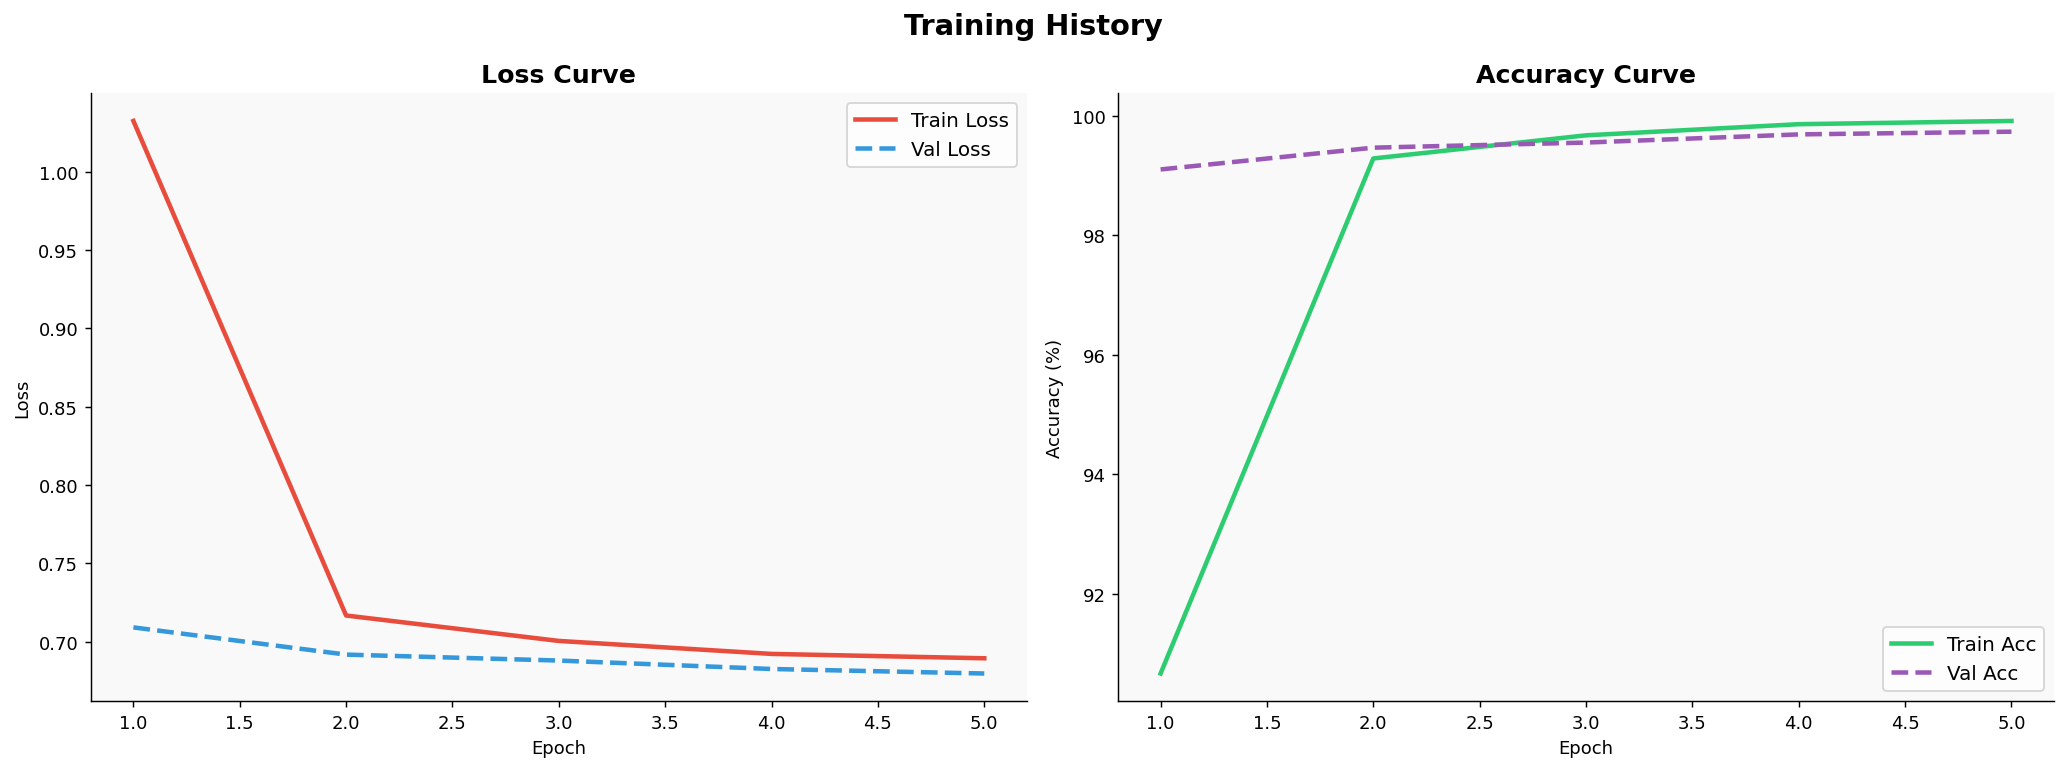

In [16]:
epochs = range(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(epochs, history["train_loss"], label="Train Loss", color="#e74c3c", linewidth=2.5)
axes[0].plot(epochs, history["val_loss"],   label="Val Loss",   color="#3498db", linewidth=2.5, linestyle="--")
axes[0].set_title("Loss Curve", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend(fontsize=11)
axes[0].spines[["top", "right"]].set_visible(False)
axes[0].set_facecolor("#f9f9f9")

axes[1].plot(epochs, [a * 100 for a in history["train_acc"]], label="Train Acc", color="#2ecc71", linewidth=2.5)
axes[1].plot(epochs, [a * 100 for a in history["val_acc"]],   label="Val Acc",   color="#9b59b6", linewidth=2.5, linestyle="--")
axes[1].set_title("Accuracy Curve", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy (%)")
axes[1].legend(fontsize=11)
axes[1].spines[["top", "right"]].set_visible(False)
axes[1].set_facecolor("#f9f9f9")

fig.suptitle("Training History", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig("/kaggle/working/training_curves.png", bbox_inches="tight")
plt.show()

<h2 style="
text-align:center;
color:#1a237e;
font-weight:bold;
font-size:32px;
text-shadow:2px 2px 8px rgba(26,35,126,0.4);
letter-spacing:1px;">
 Confusion Matrix
</h2>

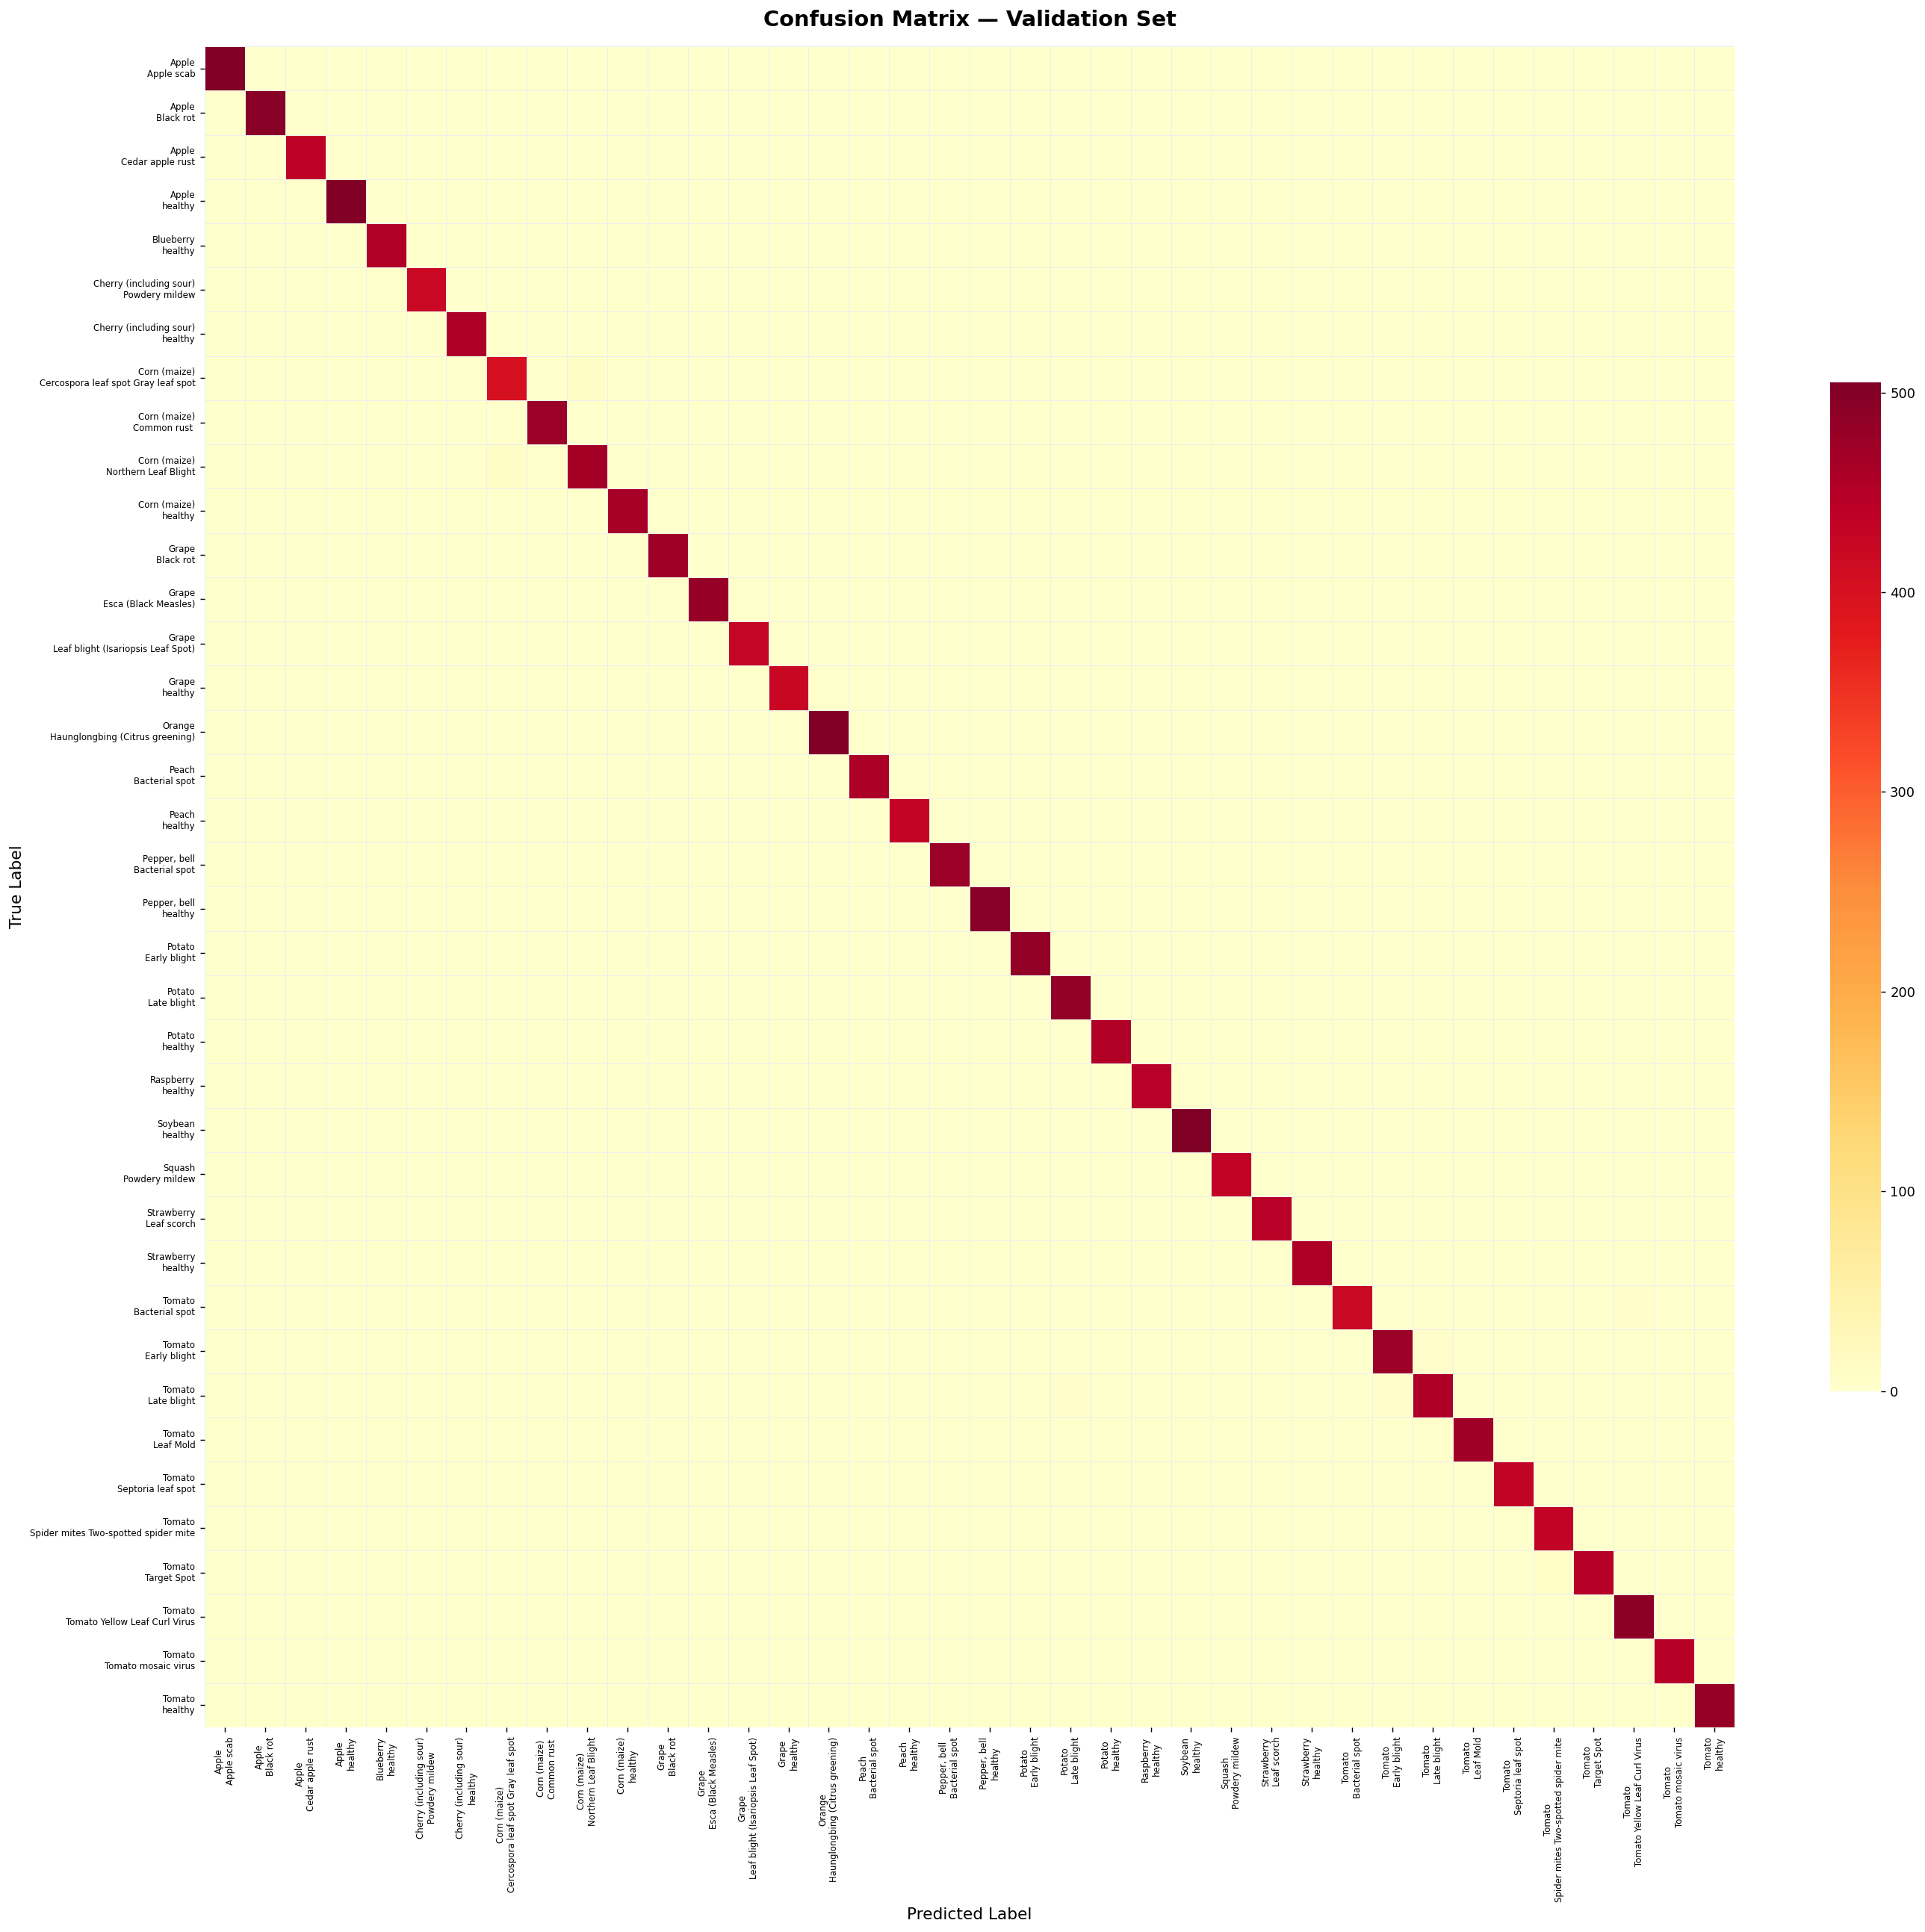

In [17]:
model.load_state_dict(torch.load(CONFIG["checkpoint_path"]))
model.eval()

all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in valid_loader:
        images = images.to(CONFIG["device"])
        outputs = model(images)
        _, preds = outputs.max(1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(22, 20))
sns.heatmap(cm, annot=False, fmt="d", cmap="YlOrRd",
            xticklabels=class_names_short,
            yticklabels=class_names_short,
            linewidths=0.3, linecolor="#eeeeee",
            cbar_kws={"shrink": 0.6})
ax.set_title("Confusion Matrix — Validation Set", fontsize=16, fontweight="bold", pad=15)
ax.set_xlabel("Predicted Label", fontsize=12)
ax.set_ylabel("True Label", fontsize=12)
ax.tick_params(axis="x", labelsize=6.5, rotation=90)
ax.tick_params(axis="y", labelsize=6.5, rotation=0)
plt.tight_layout()
plt.savefig("/kaggle/working/confusion_matrix.png", bbox_inches="tight")
plt.show()

<h2 style="
text-align:center;
color:#1a237e;
font-weight:bold;
font-size:32px;
text-shadow:2px 2px 8px rgba(26,35,126,0.4);
letter-spacing:1px;">
 Per-Class Accuracy Bar Chart
</h2>

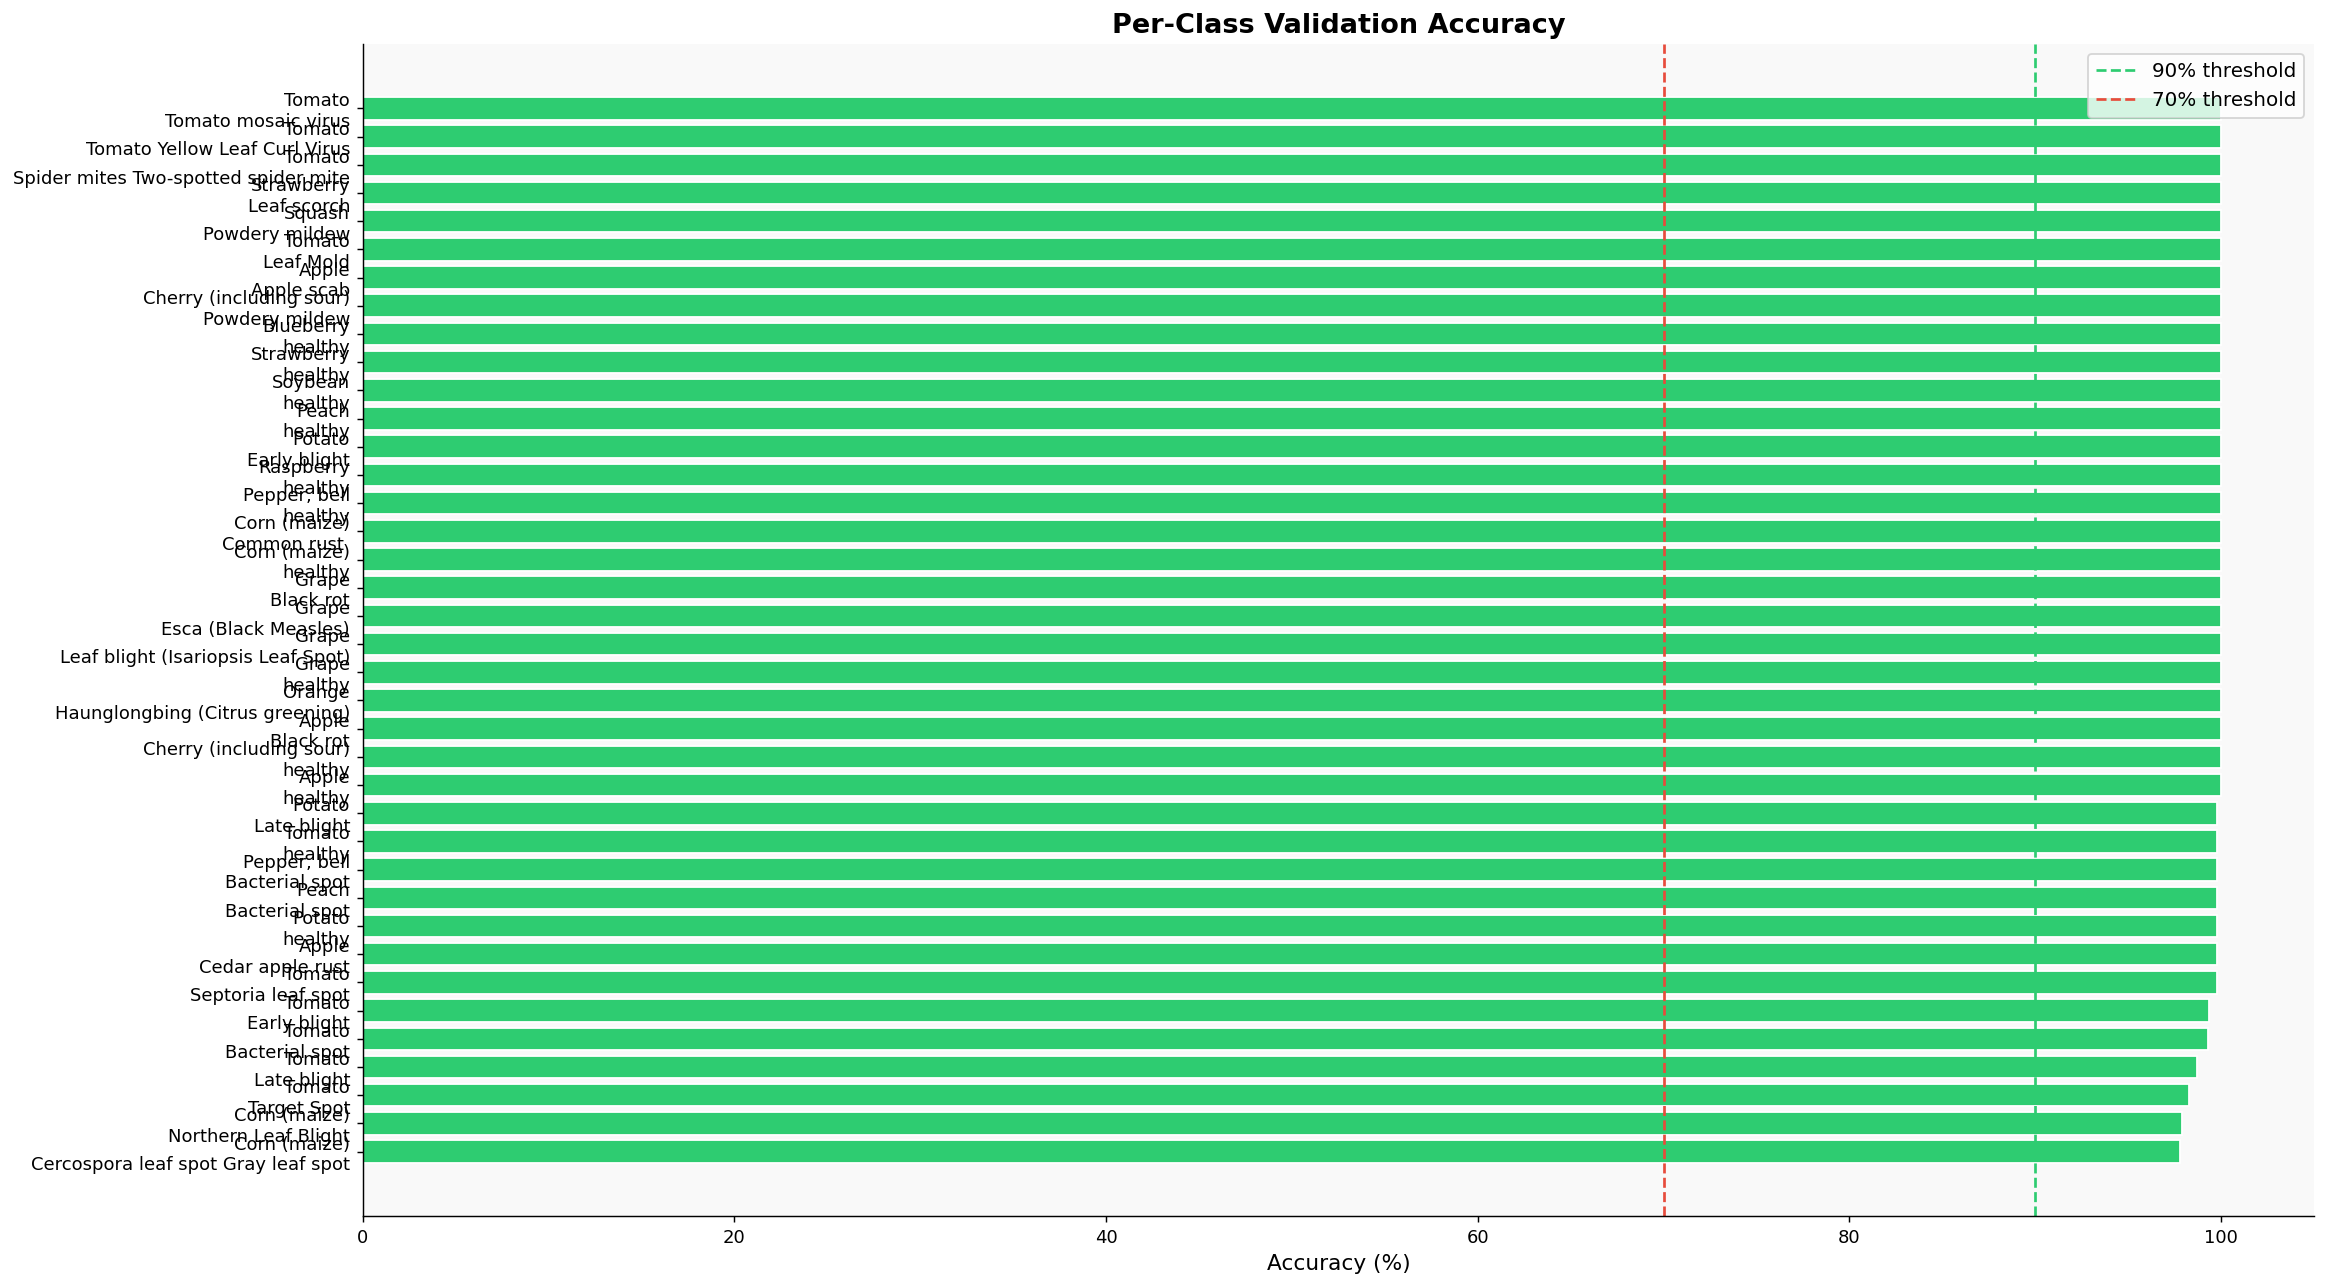

In [18]:
per_class_correct = np.zeros(num_classes)
per_class_total   = np.zeros(num_classes)

for true, pred in zip(all_labels, all_preds):
    per_class_total[true]   += 1
    if true == pred:
        per_class_correct[true] += 1

per_class_acc = per_class_correct / per_class_total * 100

sorted_idx   = np.argsort(per_class_acc)
sorted_acc   = per_class_acc[sorted_idx]
sorted_names = [class_names_short[i] for i in sorted_idx]

palette = ["#e74c3c" if a < 70 else "#f39c12" if a < 90 else "#2ecc71" for a in sorted_acc]

fig, ax = plt.subplots(figsize=(18, 10))
ax.barh(sorted_names, sorted_acc, color=palette, edgecolor="white")
ax.axvline(x=90, color="#2ecc71", linestyle="--", linewidth=1.5, label="90% threshold")
ax.axvline(x=70, color="#e74c3c", linestyle="--", linewidth=1.5, label="70% threshold")
ax.set_xlabel("Accuracy (%)", fontsize=12)
ax.set_title("Per-Class Validation Accuracy", fontsize=15, fontweight="bold")
ax.legend(fontsize=11)
ax.spines[["top", "right"]].set_visible(False)
ax.set_facecolor("#f9f9f9")
plt.tight_layout()
plt.savefig("/kaggle/working/per_class_accuracy.png", bbox_inches="tight")
plt.show()

<h2 style="
text-align:center;
color:#1a237e;
font-weight:bold;
font-size:32px;
text-shadow:2px 2px 8px rgba(26,35,126,0.4);
letter-spacing:1px;">
Classification Report</h2>

In [19]:
report = classification_report(all_labels, all_preds,
                                target_names=classes,
                                output_dict=True)

report_df = pd.DataFrame(report).transpose()
report_df = report_df.iloc[:-3].sort_values("f1-score", ascending=False)

print(f"Overall Validation Accuracy : {sum(p == l for p, l in zip(all_preds, all_labels)) / len(all_labels) * 100:.2f}%")
print(f"Macro F1 Score              : {report['macro avg']['f1-score'] * 100:.2f}%")
print(f"Weighted F1 Score           : {report['weighted avg']['f1-score'] * 100:.2f}%")

display(report_df[["precision", "recall", "f1-score", "support"]].style
        .background_gradient(cmap="RdYlGn", subset=["precision", "recall", "f1-score"])
        .format("{:.3f}", subset=["precision", "recall", "f1-score"])
        .format("{:.0f}", subset=["support"]))

Overall Validation Accuracy : 99.74%
Macro F1 Score              : 99.73%
Weighted F1 Score           : 99.74%


,precision,recall,f1-score,support
Apple___Apple_scab,1.000,1.000,1.000,504
Apple___healthy,1.000,1.000,1.000,502
Cherry_(including_sour)___Powdery_mildew,1.000,1.000,1.000,421
Grape___Black_rot,1.000,1.000,1.000,472
Grape___Esca_(Black_Measles),1.000,1.000,1.000,480
Cherry_(including_sour)___healthy,1.000,1.000,1.000,456
Potato___Early_blight,1.000,1.000,1.000,485
Squash___Powdery_mildew,1.000,1.000,1.000,434
Tomato___Tomato_mosaic_virus,1.000,1.000,1.000,448
Corn_(maize)___healthy,1.000,1.000,1.000,465


<h2 style="
text-align:center;
color:#1a237e;
font-weight:bold;
font-size:32px;
text-shadow:2px 2px 8px rgba(26,35,126,0.4);
letter-spacing:1px;">
Grad-CAM Function
</h2>

In [20]:
def generate_gradcam(model, image_tensor, target_class=None):
    model.eval()
    image_tensor = image_tensor.unsqueeze(0).to(CONFIG["device"])
    output       = model(image_tensor)

    if target_class is None:
        target_class = output.argmax(1).item()

    model.zero_grad()
    output[0, target_class].backward()

    gradients   = model.gradients.detach().cpu()
    activations = model.activations.detach().cpu()

    weights  = gradients.mean(dim=[2, 3], keepdim=True)
    cam      = (weights * activations).sum(dim=1, keepdim=True)
    cam      = torch.relu(cam)
    cam      = cam - cam.min()
    cam      = cam / (cam.max() + 1e-8)
    cam      = cam.squeeze().numpy()
    cam      = cv2.resize(cam, (CONFIG["image_size"], CONFIG["image_size"]))
    return cam, target_class

<h2 style="
text-align:center;
color:#1a237e;
font-weight:bold;
font-size:32px;
text-shadow:2px 2px 8px rgba(26,35,126,0.4);
letter-spacing:1px;">
Grad-CAM Visualization Grid</h2>

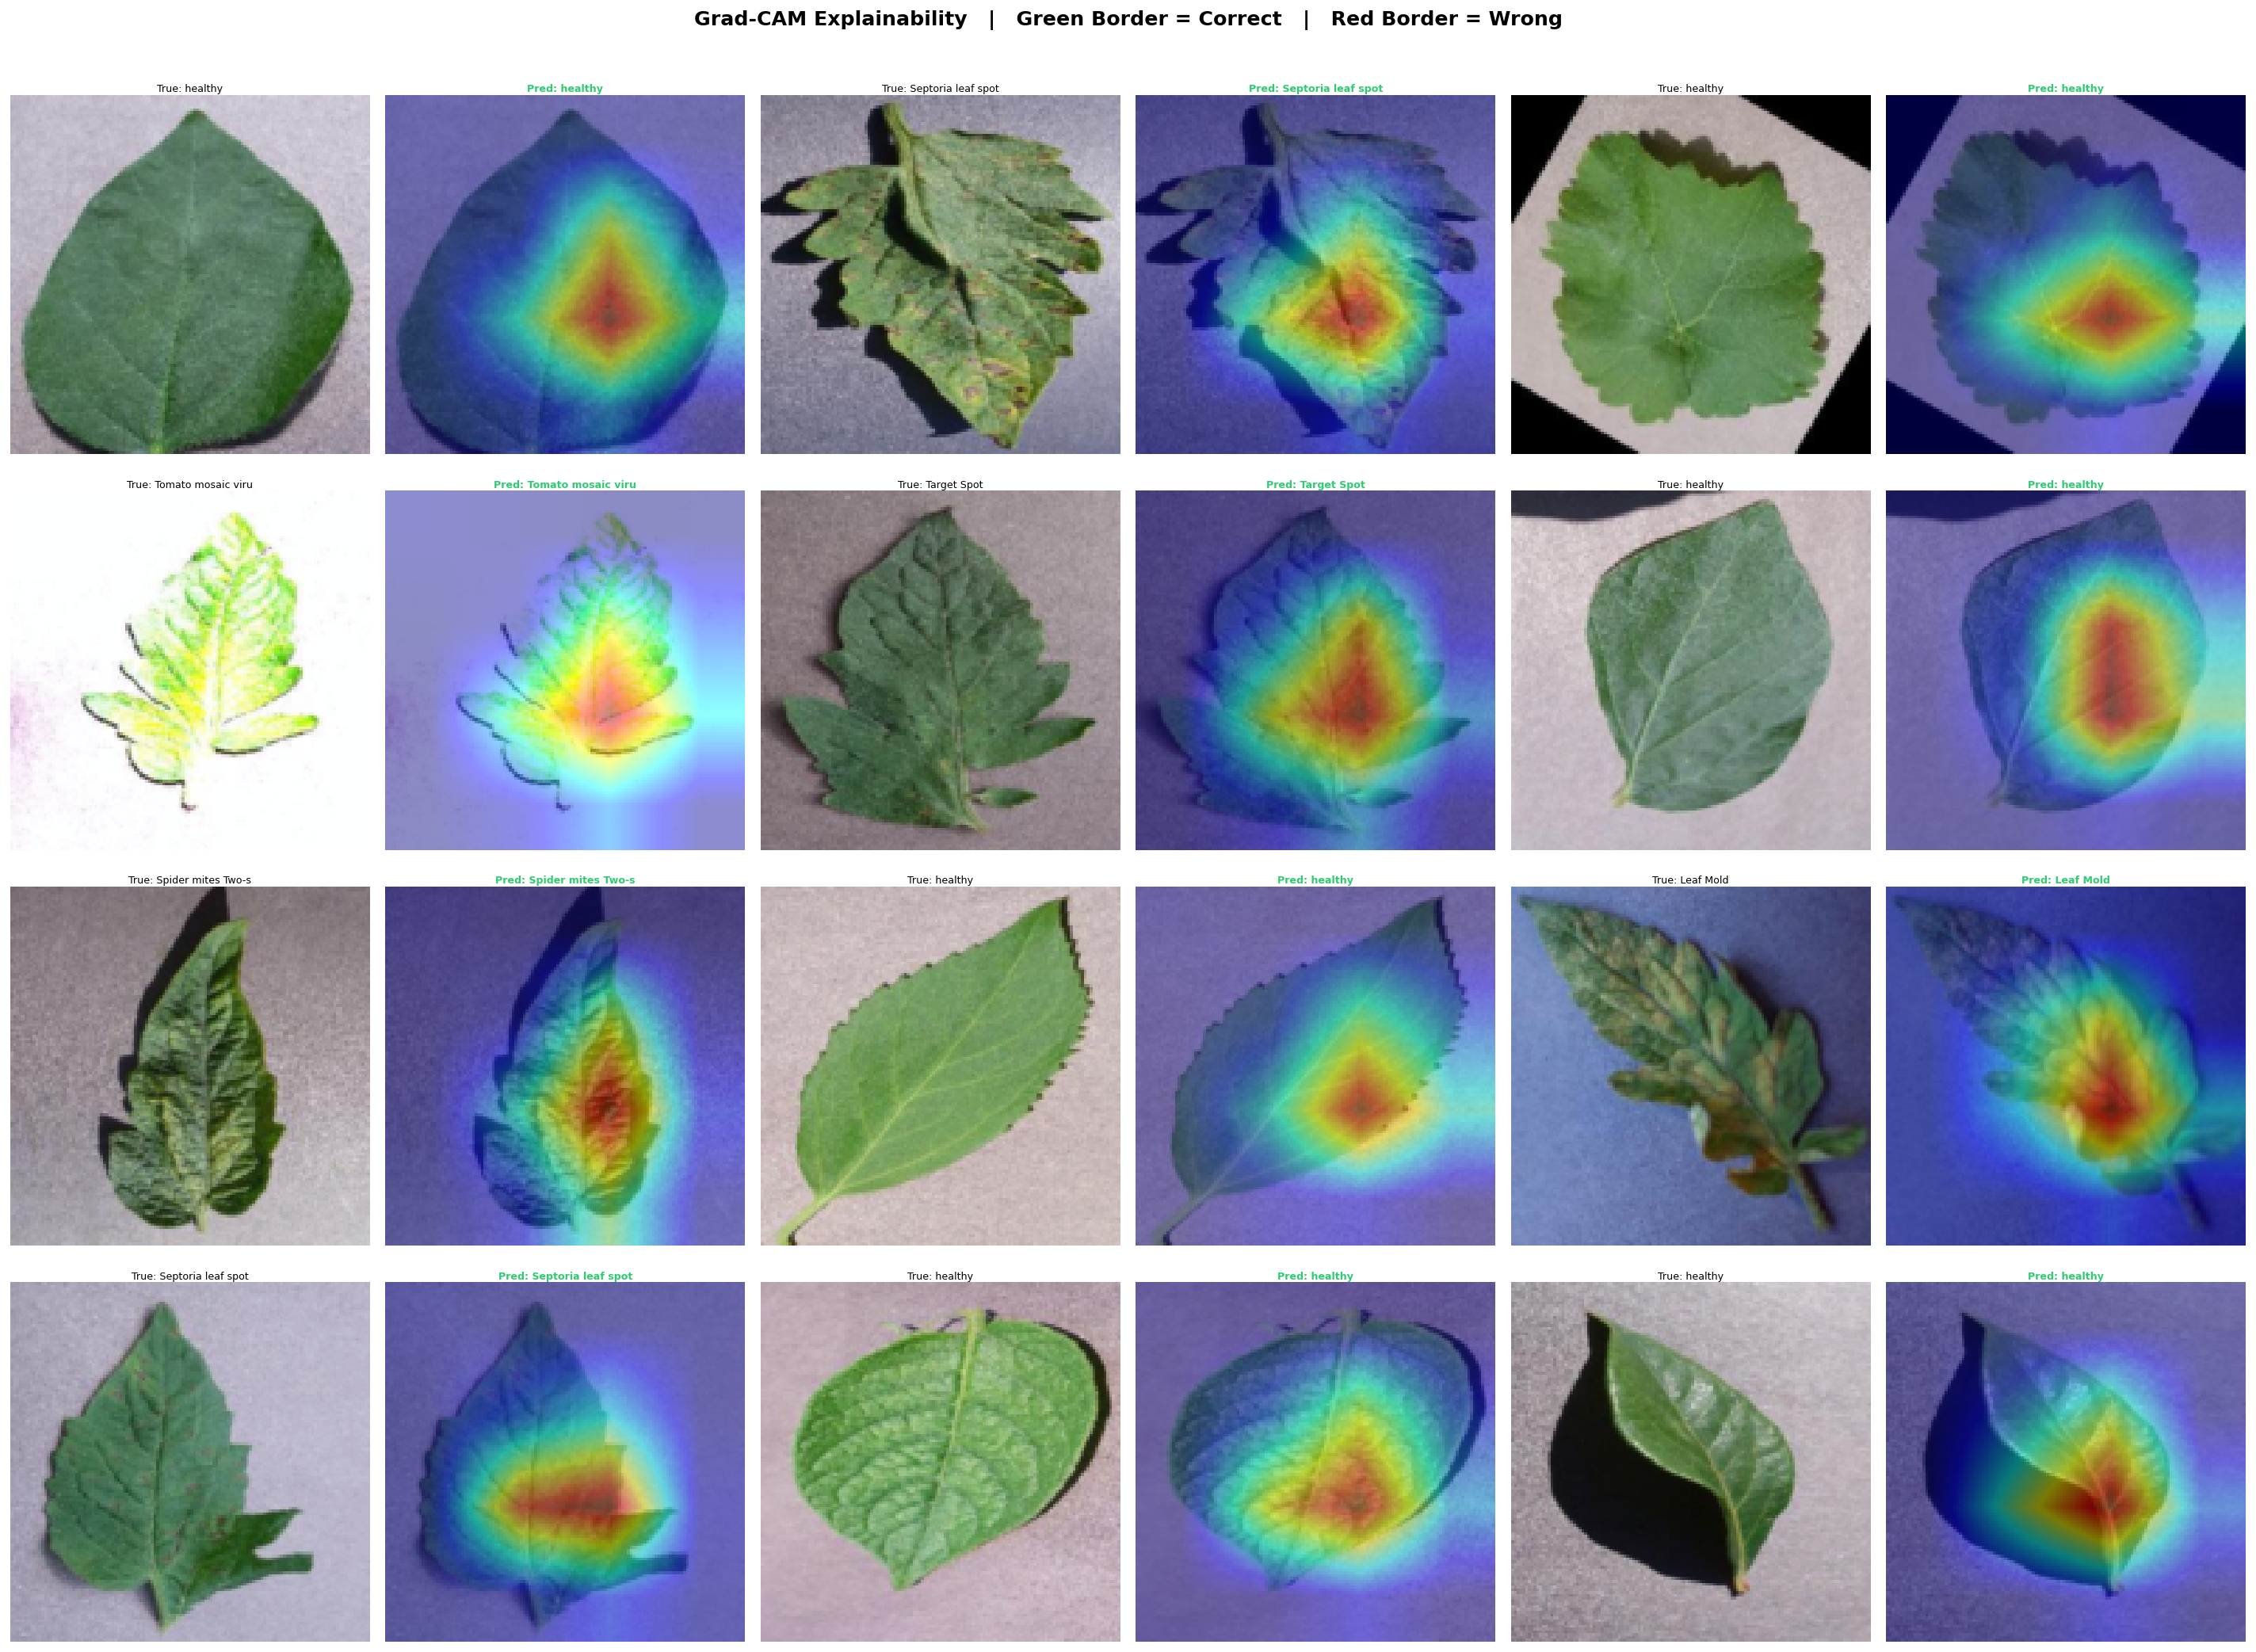

In [21]:
mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])

def denormalize(tensor):
    img = tensor.permute(1, 2, 0).numpy()
    img = img * std + mean
    return np.clip(img, 0, 1)

sample_indices = random.sample(range(len(valid_dataset)), 12)

fig, axes = plt.subplots(4, 6, figsize=(22, 16))

for plot_idx, sample_idx in enumerate(sample_indices):
    img_tensor, true_label = valid_dataset[sample_idx]
    cam, pred_label        = generate_gradcam(model, img_tensor)

    raw_img = denormalize(img_tensor)

    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) / 255.0
    overlay = 0.55 * raw_img + 0.45 * heatmap
    overlay = np.clip(overlay, 0, 1)

    row = plot_idx // 3
    col = (plot_idx % 3) * 2

    axes[row][col].imshow(raw_img)
    axes[row][col].set_title(
        f"True: {classes[true_label].split('___')[-1][:18].replace('_', ' ')}",
        fontsize=7, pad=2)
    axes[row][col].axis("off")

    correct      = pred_label == true_label
    border_color = "#2ecc71" if correct else "#e74c3c"
    for spine in axes[row][col + 1].spines.values():
        spine.set_edgecolor(border_color)
        spine.set_linewidth(2.5)

    axes[row][col + 1].imshow(overlay)
    axes[row][col + 1].set_title(
        f"Pred: {classes[pred_label].split('___')[-1][:18].replace('_', ' ')}",
        fontsize=7, color=border_color, fontweight="bold", pad=2)
    axes[row][col + 1].axis("off")

fig.suptitle("Grad-CAM Explainability   |   Green Border = Correct   |   Red Border = Wrong",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("/kaggle/working/gradcam_grid.png", bbox_inches="tight")
plt.show()